# Partea 1 – Analiza si intelegerea setului de date
## Dataset: Australian Credit Approval (UCI)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



---
## 1. Descrierea generala a setului de date si a variabilei tinta

Sursa:[Australian Credit Approval](https://archive.ics.uci.edu/ml/datasets/Statlog+%28Australian+Credit+Approval%29)

Scopul problemei: Prezicerea daca o cerere de credit este aprobata sau respinsa pe baza unor caracteristici personale si financiare. Variabila tinta este **A15**.

Tipul problemei: Clasificare binara (0 = respins, 1 = aprobat)

Numarul de trasaturi:690
Tipul trasaturilor:

| Variable Name | Role    | Type        | Missing Values |
|---------------|---------|-------------|----------------|
| A1            | Feature | Categorical | no             |
| A2            | Feature | Continuous  | no             |  
| A3            | Feature | Continuous  | no             |
| A4            | Feature | Categorical | no             |
| A5            | Feature | Categorical | no             |
| A6            | Feature | Categorical | no             |
| A7            | Feature | Continuous  | no             |
| A8            | Feature | Categorical | no             |
| A9            | Feature | Categorical | no             |
| A10           | Feature | Continuous  | no             |
| A11           | Feature | Categorical | no             |
| A12           | Feature | Categorical | no             |
| A13           | Feature | Continuous  | no             |
| A14           | Feature | Continuous  | no             |
| A15           | Target  | Categorical | no             |

In [4]:
# Citirea setului de date
col_names = ['A1','A2','A3','A4','A5','A6','A7','A8','A9','A10','A11','A12','A13','A14','A15']
df = pd.read_csv('australian.dat', sep=' ', header=None, names=col_names)

# Numarul de instante si trasaturi
n_instante, n_trasaturi = df.shape
print(f"Numar de instante (randuri): {n_instante}")
print(f"Numar de trasaturi (coloane, inclusiv target): {n_trasaturi}")
print(f"Numar de trasaturi (fara target): {n_trasaturi - 1}")
print()
print("Primele 5 randuri:")
df.head()

Numar de instante (randuri): 690
Numar de trasaturi (coloane, inclusiv target): 15
Numar de trasaturi (fara target): 14

Primele 5 randuri:


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15
0,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1


---
## 2. Distributia claselor

In [22]:
# Distributia claselor – tabel
class_counts = df['A15'].value_counts().sort_index()
# print(class_counts)
# print(class_counts.sum())
class_pct = class_counts/class_counts.sum() * 100

dist = pd.DataFrame({

    'Nr. instante': class_counts.values,
    'Procent (%)': class_pct.values.round(2)
})
print("Distributia claselor:")
print(dist)

Distributia claselor:
   Nr. instante  Procent (%)
0           383        55.51
1           307        44.49


C:\Users\Tavi\AppData\Local\Temp\ipykernel_11304\934044225.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='A15', data=df, palette='Set2', ax=axes[0])


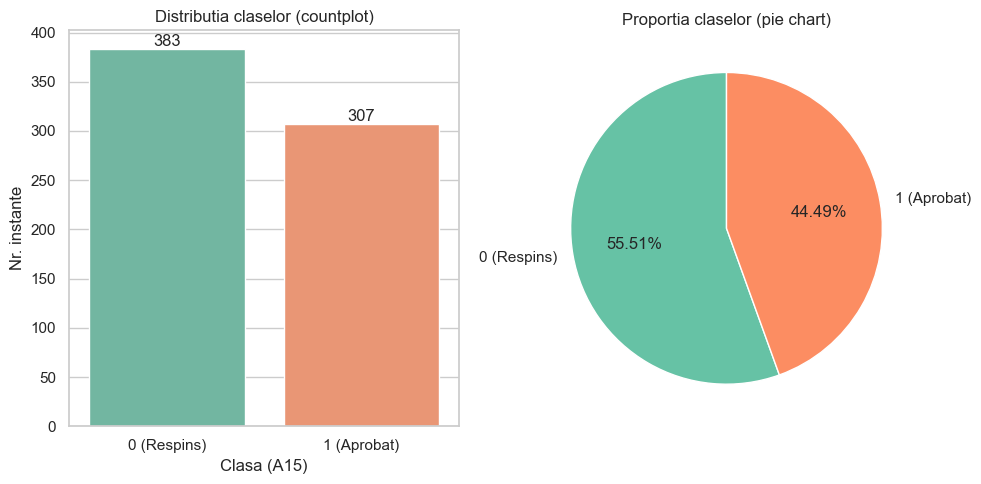


Concluzie: Dataset-ul este relativ echilibrat – clasa 0: 55.51%, clasa 1: 44.49%.


In [24]:
# Grafic distributie clase
fig, axes = plt.subplots(1, 2)

# Countplot
sns.countplot(x='A15', data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Distributia claselor (countplot)')
axes[0].set_xlabel('Clasa (A15)')
axes[0].set_ylabel('Nr. instante')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['0 (Respins)', '1 (Aprobat)'])
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=12)

# Pie chart
axes[1].pie(class_counts.values, labels=['0 (Respins)', '1 (Aprobat)'],
            autopct='%1.2f%%', colors=sns.color_palette('Set2'), startangle=90)
axes[1].set_title('Proportia claselor (pie chart)')

plt.tight_layout()
plt.show()

print("\nConcluzie: Dataset-ul este relativ echilibrat –",
      f"clasa 0: {class_pct[0]:.2f}%, clasa 1: {class_pct[1]:.2f}%.")